# 04 — Predictive Modelling of Airport Taxi Demand

This notebook evaluates whether scheduled flight-arrival information improves prediction of hourly Yellow Taxi pickup demand at JFK and LaGuardia Airport.

Models are trained using January–May 2025 observations and evaluated on the held-out June 2025 period. A chronological split is used to prevent future information from leaking into model training.

Two contrasting modelling approaches are considered:

1. Linear Regression as an interpretable baseline.
2. Gradient-Boosted Tree Regression as a more flexible nonlinear model.

For each modelling approach, a temporal baseline is compared with a flight-informed specification that additionally includes scheduled arrivals from the preceding hour.

In [50]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import Window

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer,
    OneHotEncoder,
    VectorAssembler
)
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

spark = (
    SparkSession.builder
    .appName("MAST30034_Project1_Modelling")
    .getOrCreate()
)

print("Spark version:", spark.version)

Spark version: 4.2.0


In [51]:
TAXI_PATH = "../data/processed/hourly_airport_taxi_demand.parquet"
FLIGHT_PATH = "../data/processed/hourly_flight_arrivals.parquet"

taxi = spark.read.parquet(TAXI_PATH)
flights = spark.read.parquet(FLIGHT_PATH)

print("Taxi rows:", taxi.count())
print("Flight rows:", flights.count())

Taxi rows: 8688
Flight rows: 8688


In [52]:
taxi_model = taxi.select(
    "airport",
    F.col("pickup_hour").alias("hour"),
    "taxi_pickups"
)

flight_model = flights.select(
    "airport",
    F.col("arrival_hour").alias("hour"),
    "scheduled_arrivals"
)

In [53]:
model_panel = (
    taxi_model
    .join(
        flight_model,
        on=["airport", "hour"],
        how="inner"
    )
    .orderBy("airport", "hour")
)

print("Merged modelling-panel rows:", model_panel.count())

Merged modelling-panel rows: 8688


In [54]:
model_panel = (
    model_panel
    .withColumn("hour_of_day", F.hour("hour"))
    .withColumn("day_of_week", F.dayofweek("hour"))
    .withColumn("month", F.month("hour"))
)

In [55]:
model_window = (
    Window
    .partitionBy("airport")
    .orderBy("hour")
)

model_panel = (
    model_panel
    .withColumn(
        "scheduled_arrivals_lag_1",
        F.lag("scheduled_arrivals", 1).over(model_window)
    )
)

In [56]:
model_panel = model_panel.filter(
    F.col("scheduled_arrivals_lag_1").isNotNull()
)

print("Final modelling rows:", model_panel.count())

Final modelling rows: 8686


In [57]:
train_data = model_panel.filter(
    F.col("hour") < F.lit("2025-06-01 00:00:00")
)

test_data = model_panel.filter(
    F.col("hour") >= F.lit("2025-06-01 00:00:00")
)

print("Training rows:", train_data.count())
print("Test rows:", test_data.count())

Training rows: 7246
Test rows: 1440


## 2. Linear Regression

Linear Regression is used as an interpretable baseline model.

Two specifications are compared:

- **Temporal baseline:** airport, hour of day, day of week, and month.
- **Flight-informed model:** the same predictors plus scheduled flight arrivals from the preceding hour.

Both models are evaluated on the same unseen June 2025 test set.

In [58]:
airport_indexer = StringIndexer(
    inputCol="airport",
    outputCol="airport_index",
    handleInvalid="keep"
)

hour_indexer = StringIndexer(
    inputCol="hour_of_day",
    outputCol="hour_index",
    handleInvalid="keep"
)

dow_indexer = StringIndexer(
    inputCol="day_of_week",
    outputCol="dow_index",
    handleInvalid="keep"
)

month_indexer = StringIndexer(
    inputCol="month",
    outputCol="month_index",
    handleInvalid="keep"
)

In [59]:
encoder = OneHotEncoder(
    inputCols=[
        "airport_index",
        "hour_index",
        "dow_index",
        "month_index"
    ],
    outputCols=[
        "airport_vec",
        "hour_vec",
        "dow_vec",
        "month_vec"
    ],
    dropLast=True
)

In [60]:
baseline_assembler = VectorAssembler(
    inputCols=[
        "airport_vec",
        "hour_vec",
        "dow_vec",
        "month_vec"
    ],
    outputCol="features"
)

lr_baseline = LinearRegression(
    featuresCol="features",
    labelCol="taxi_pickups",
    predictionCol="prediction"
)

In [61]:
baseline_pipeline = Pipeline(
    stages=[
        airport_indexer,
        hour_indexer,
        dow_indexer,
        month_indexer,
        encoder,
        baseline_assembler,
        lr_baseline
    ]
)

In [62]:
baseline_lr_model = baseline_pipeline.fit(train_data)

26/08/31 20:06:59 WARN Instrumentation: [86189d36] regParam is zero, which might cause numerical instability and overfitting.
26/08/31 20:06:59 WARN Instrumentation: [86189d36] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


In [63]:
baseline_predictions = baseline_lr_model.transform(test_data)

In [64]:
baseline_predictions.select(
    "airport",
    "hour",
    "taxi_pickups",
    "prediction"
).show(10, truncate=False)

+-------+-------------------+------------+------------------+
|airport|hour               |taxi_pickups|prediction        |
+-------+-------------------+------------+------------------+
|JFK    |2025-06-01 00:00:00|347         |217.14436887210744|
|JFK    |2025-06-01 01:00:00|103         |125.74471789623506|
|JFK    |2025-06-01 02:00:00|20          |79.95663833757803 |
|JFK    |2025-06-01 03:00:00|15          |67.4864396379901  |
|JFK    |2025-06-01 04:00:00|25          |67.51624096255098 |
|JFK    |2025-06-01 05:00:00|71          |97.44008207996367 |
|JFK    |2025-06-01 06:00:00|148         |133.05266493022089|
|JFK    |2025-06-01 07:00:00|133         |161.28445306423237|
|JFK    |2025-06-01 08:00:00|142         |158.32418815785115|
|JFK    |2025-06-01 09:00:00|156         |187.73809549944437|
+-------+-------------------+------------+------------------+
only showing top 10 rows


In [65]:
rmse_evaluator = RegressionEvaluator(
    labelCol="taxi_pickups",
    predictionCol="prediction",
    metricName="rmse"
)

mae_evaluator = RegressionEvaluator(
    labelCol="taxi_pickups",
    predictionCol="prediction",
    metricName="mae"
)

r2_evaluator = RegressionEvaluator(
    labelCol="taxi_pickups",
    predictionCol="prediction",
    metricName="r2"
)

In [66]:
baseline_rmse = rmse_evaluator.evaluate(
    baseline_predictions
)

baseline_mae = mae_evaluator.evaluate(
    baseline_predictions
)

baseline_r2 = r2_evaluator.evaluate(
    baseline_predictions
)

print(f"Baseline LR RMSE: {baseline_rmse:.2f}")
print(f"Baseline LR MAE:  {baseline_mae:.2f}")
print(f"Baseline LR R²:   {baseline_r2:.4f}")

Baseline LR RMSE: 83.46
Baseline LR MAE:  59.92
Baseline LR R²:   0.6787


### 2.2 Flight-Informed Linear Regression

The second linear regression model extends the temporal baseline by adding the number of scheduled flight arrivals in the preceding hour (`scheduled_arrivals_lag_1`).

All other predictors, the training period, and the held-out June 2025 test period are kept unchanged. This allows any change in predictive performance to be attributed specifically to the additional flight-schedule information.

In [67]:
flight_assembler = VectorAssembler(
    inputCols=[
        "airport_vec",
        "hour_vec",
        "dow_vec",
        "month_vec",
        "scheduled_arrivals_lag_1"
    ],
    outputCol="features"
)

In [68]:
lr_flight = LinearRegression(
    featuresCol="features",
    labelCol="taxi_pickups",
    predictionCol="prediction"
)

In [69]:
flight_pipeline = Pipeline(
    stages=[
        airport_indexer,
        hour_indexer,
        dow_indexer,
        month_indexer,
        encoder,
        flight_assembler,
        lr_flight
    ]
)

In [70]:
flight_lr_model = flight_pipeline.fit(train_data)

26/08/31 20:07:00 WARN Instrumentation: [2e3780eb] regParam is zero, which might cause numerical instability and overfitting.
26/08/31 20:07:00 WARN Instrumentation: [2e3780eb] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


In [71]:
flight_predictions = flight_lr_model.transform(test_data)

In [72]:
flight_predictions.select(
    "airport",
    "hour",
    "scheduled_arrivals_lag_1",
    "taxi_pickups",
    "prediction"
).show(10, truncate=False)

+-------+-------------------+------------------------+------------+------------------+
|airport|hour               |scheduled_arrivals_lag_1|taxi_pickups|prediction        |
+-------+-------------------+------------------------+------------+------------------+
|JFK    |2025-06-01 00:00:00|15                      |347         |223.47225104243327|
|JFK    |2025-06-01 01:00:00|9                       |103         |148.47163197756936|
|JFK    |2025-06-01 02:00:00|1                       |20          |87.05700730493137 |
|JFK    |2025-06-01 03:00:00|0                       |15          |73.1208020562143  |
|JFK    |2025-06-01 04:00:00|0                       |25          |73.17232199694291 |
|JFK    |2025-06-01 05:00:00|0                       |71          |101.43468837015755|
|JFK    |2025-06-01 06:00:00|12                      |148         |165.661549950957  |
|JFK    |2025-06-01 07:00:00|9                       |133         |183.82675823307784|
|JFK    |2025-06-01 08:00:00|25            

In [73]:
flight_rmse = rmse_evaluator.evaluate(
    flight_predictions
)

flight_mae = mae_evaluator.evaluate(
    flight_predictions
)

flight_r2 = r2_evaluator.evaluate(
    flight_predictions
)

print(f"Flight-informed LR RMSE: {flight_rmse:.2f}")
print(f"Flight-informed LR MAE:  {flight_mae:.2f}")
print(f"Flight-informed LR R²:   {flight_r2:.4f}")

Flight-informed LR RMSE: 82.74
Flight-informed LR MAE:  59.29
Flight-informed LR R²:   0.6843


In [74]:
rmse_improvement = (
    (baseline_rmse - flight_rmse)
    / baseline_rmse
    * 100
)

mae_improvement = (
    (baseline_mae - flight_mae)
    / baseline_mae
    * 100
)

print("Linear Regression Model Comparison")
print("----------------------------------")
print(f"Baseline RMSE:        {baseline_rmse:.2f}")
print(f"Flight-informed RMSE: {flight_rmse:.2f}")
print(f"RMSE improvement:     {rmse_improvement:.2f}%")
print()
print(f"Baseline MAE:         {baseline_mae:.2f}")
print(f"Flight-informed MAE:  {flight_mae:.2f}")
print(f"MAE improvement:      {mae_improvement:.2f}%")
print()
print(f"Baseline R²:          {baseline_r2:.4f}")
print(f"Flight-informed R²:   {flight_r2:.4f}")

Linear Regression Model Comparison
----------------------------------
Baseline RMSE:        83.46
Flight-informed RMSE: 82.74
RMSE improvement:     0.87%

Baseline MAE:         59.92
Flight-informed MAE:  59.29
MAE improvement:      1.05%

Baseline R²:          0.6787
Flight-informed R²:   0.6843


In [75]:
for airport in ["JFK", "LGA"]:
    print(f"\n{airport}")

    baseline_airport = baseline_predictions.filter(
        F.col("airport") == airport
    )

    flight_airport = flight_predictions.filter(
        F.col("airport") == airport
    )

    airport_baseline_rmse = rmse_evaluator.evaluate(
        baseline_airport
    )

    airport_flight_rmse = rmse_evaluator.evaluate(
        flight_airport
    )

    airport_baseline_mae = mae_evaluator.evaluate(
        baseline_airport
    )

    airport_flight_mae = mae_evaluator.evaluate(
        flight_airport
    )

    airport_rmse_improvement = (
        (airport_baseline_rmse - airport_flight_rmse)
        / airport_baseline_rmse
        * 100
    )

    print(f"Baseline RMSE:        {airport_baseline_rmse:.2f}")
    print(f"Flight-informed RMSE: {airport_flight_rmse:.2f}")
    print(f"RMSE improvement:     {airport_rmse_improvement:.2f}%")
    print(f"Baseline MAE:         {airport_baseline_mae:.2f}")
    print(f"Flight-informed MAE:  {airport_flight_mae:.2f}")


JFK
Baseline RMSE:        95.38
Flight-informed RMSE: 96.75
RMSE improvement:     -1.44%
Baseline MAE:         67.38
Flight-informed MAE:  68.94

LGA
Baseline RMSE:        69.53
Flight-informed RMSE: 65.81
RMSE improvement:     5.35%
Baseline MAE:         52.46
Flight-informed MAE:  49.64


## 3. Gradient-Boosted Tree Regression

Gradient-Boosted Tree (GBT) regression is used as a more flexible alternative to Linear Regression. Unlike the linear model, GBT can capture nonlinear relationships and interactions between temporal, airport, and flight-arrival predictors without requiring these relationships to be specified manually.

As with Linear Regression, two specifications are compared:

- **Temporal baseline:** airport, hour of day, day of week, and month.
- **Flight-informed model:** the same temporal predictors plus scheduled flight arrivals from the preceding hour.

Both models use the same January–May 2025 training period and June 2025 test period used in the Linear Regression analysis.

In [76]:
from pyspark.ml.regression import GBTRegressor

In [77]:
gbt_airport_indexer = StringIndexer(
    inputCol="airport",
    outputCol="gbt_airport_index",
    handleInvalid="keep"
)

gbt_hour_indexer = StringIndexer(
    inputCol="hour_of_day",
    outputCol="gbt_hour_index",
    handleInvalid="keep"
)

gbt_dow_indexer = StringIndexer(
    inputCol="day_of_week",
    outputCol="gbt_dow_index",
    handleInvalid="keep"
)

gbt_month_indexer = StringIndexer(
    inputCol="month",
    outputCol="gbt_month_index",
    handleInvalid="keep"
)

In [78]:
gbt_baseline_assembler = VectorAssembler(
    inputCols=[
        "gbt_airport_index",
        "gbt_hour_index",
        "gbt_dow_index",
        "gbt_month_index"
    ],
    outputCol="features"
)

In [79]:
gbt_baseline = GBTRegressor(
    featuresCol="features",
    labelCol="taxi_pickups",
    predictionCol="prediction",
    maxIter=50,
    maxDepth=5,
    seed=42
)

In [80]:
gbt_baseline_pipeline = Pipeline(
    stages=[
        gbt_airport_indexer,
        gbt_hour_indexer,
        gbt_dow_indexer,
        gbt_month_indexer,
        gbt_baseline_assembler,
        gbt_baseline
    ]
)

In [81]:
gbt_baseline_model = gbt_baseline_pipeline.fit(train_data)

In [82]:
gbt_baseline_predictions = gbt_baseline_model.transform(test_data)

In [83]:
gbt_baseline_predictions.select(
    "airport",
    "hour",
    "taxi_pickups",
    "prediction"
).show(10, truncate=False)

+-------+-------------------+------------+------------------+
|airport|hour               |taxi_pickups|prediction        |
+-------+-------------------+------------+------------------+
|JFK    |2025-06-01 00:00:00|347         |193.92641612010152|
|JFK    |2025-06-01 01:00:00|103         |130.5347830955028 |
|JFK    |2025-06-01 02:00:00|20          |45.95674512471611 |
|JFK    |2025-06-01 03:00:00|15          |23.29602537818731 |
|JFK    |2025-06-01 04:00:00|25          |19.049951149667642|
|JFK    |2025-06-01 05:00:00|71          |78.7358649071004  |
|JFK    |2025-06-01 06:00:00|148         |169.1126370096119 |
|JFK    |2025-06-01 07:00:00|133         |189.9001653857359 |
|JFK    |2025-06-01 08:00:00|142         |151.54613179547056|
|JFK    |2025-06-01 09:00:00|156         |147.6856868965722 |
+-------+-------------------+------------+------------------+
only showing top 10 rows


In [84]:
gbt_baseline_rmse = rmse_evaluator.evaluate(
    gbt_baseline_predictions
)

gbt_baseline_mae = mae_evaluator.evaluate(
    gbt_baseline_predictions
)

gbt_baseline_r2 = r2_evaluator.evaluate(
    gbt_baseline_predictions
)

print(f"Baseline GBT RMSE: {gbt_baseline_rmse:.2f}")
print(f"Baseline GBT MAE:  {gbt_baseline_mae:.2f}")
print(f"Baseline GBT R²:   {gbt_baseline_r2:.4f}")

Baseline GBT RMSE: 62.40
Baseline GBT MAE:  43.95
Baseline GBT R²:   0.8204


In [85]:
gbt_flight_assembler = VectorAssembler(
    inputCols=[
        "gbt_airport_index",
        "gbt_hour_index",
        "gbt_dow_index",
        "gbt_month_index",
        "scheduled_arrivals_lag_1"
    ],
    outputCol="features"
)

In [86]:
gbt_flight = GBTRegressor(
    featuresCol="features",
    labelCol="taxi_pickups",
    predictionCol="prediction",
    maxIter=50,
    maxDepth=5,
    seed=42
)

In [87]:
gbt_flight_pipeline = Pipeline(
    stages=[
        gbt_airport_indexer,
        gbt_hour_indexer,
        gbt_dow_indexer,
        gbt_month_indexer,
        gbt_flight_assembler,
        gbt_flight
    ]
)

In [88]:
gbt_flight_model = gbt_flight_pipeline.fit(train_data)

In [89]:
gbt_flight_predictions = gbt_flight_model.transform(test_data)

In [90]:
gbt_flight_predictions.select(
    "airport",
    "hour",
    "scheduled_arrivals_lag_1",
    "taxi_pickups",
    "prediction"
).show(10, truncate=False)

+-------+-------------------+------------------------+------------+------------------+
|airport|hour               |scheduled_arrivals_lag_1|taxi_pickups|prediction        |
+-------+-------------------+------------------------+------------+------------------+
|JFK    |2025-06-01 00:00:00|15                      |347         |202.35281165665162|
|JFK    |2025-06-01 01:00:00|9                       |103         |119.88020113468177|
|JFK    |2025-06-01 02:00:00|1                       |20          |37.44861153339399 |
|JFK    |2025-06-01 03:00:00|0                       |15          |29.34192696392557 |
|JFK    |2025-06-01 04:00:00|0                       |25          |27.61640480865833 |
|JFK    |2025-06-01 05:00:00|0                       |71          |55.80550880370997 |
|JFK    |2025-06-01 06:00:00|12                      |148         |175.96075217554122|
|JFK    |2025-06-01 07:00:00|9                       |133         |188.2918874663049 |
|JFK    |2025-06-01 08:00:00|25            

In [91]:
gbt_flight_rmse = rmse_evaluator.evaluate(
    gbt_flight_predictions
)

gbt_flight_mae = mae_evaluator.evaluate(
    gbt_flight_predictions
)

gbt_flight_r2 = r2_evaluator.evaluate(
    gbt_flight_predictions
)

print(f"Flight-informed GBT RMSE: {gbt_flight_rmse:.2f}")
print(f"Flight-informed GBT MAE:  {gbt_flight_mae:.2f}")
print(f"Flight-informed GBT R²:   {gbt_flight_r2:.4f}")

Flight-informed GBT RMSE: 65.47
Flight-informed GBT MAE:  47.62
Flight-informed GBT R²:   0.8023


In [92]:
gbt_rmse_improvement = (
    (gbt_baseline_rmse - gbt_flight_rmse)
    / gbt_baseline_rmse
    * 100
)

gbt_mae_improvement = (
    (gbt_baseline_mae - gbt_flight_mae)
    / gbt_baseline_mae
    * 100
)

print("Gradient-Boosted Tree Model Comparison")
print("--------------------------------------")
print(f"Baseline RMSE:        {gbt_baseline_rmse:.2f}")
print(f"Flight-informed RMSE: {gbt_flight_rmse:.2f}")
print(f"RMSE improvement:     {gbt_rmse_improvement:.2f}%")
print()
print(f"Baseline MAE:         {gbt_baseline_mae:.2f}")
print(f"Flight-informed MAE:  {gbt_flight_mae:.2f}")
print(f"MAE improvement:      {gbt_mae_improvement:.2f}%")
print()
print(f"Baseline R²:          {gbt_baseline_r2:.4f}")
print(f"Flight-informed R²:   {gbt_flight_r2:.4f}")

Gradient-Boosted Tree Model Comparison
--------------------------------------
Baseline RMSE:        62.40
Flight-informed RMSE: 65.47
RMSE improvement:     -4.92%

Baseline MAE:         43.95
Flight-informed MAE:  47.62
MAE improvement:      -8.37%

Baseline R²:          0.8204
Flight-informed R²:   0.8023


In [93]:
for airport in ["JFK", "LGA"]:
    print(f"\n{airport}")

    baseline_airport = gbt_baseline_predictions.filter(
        F.col("airport") == airport
    )

    flight_airport = gbt_flight_predictions.filter(
        F.col("airport") == airport
    )

    airport_baseline_rmse = rmse_evaluator.evaluate(
        baseline_airport
    )

    airport_flight_rmse = rmse_evaluator.evaluate(
        flight_airport
    )

    airport_baseline_mae = mae_evaluator.evaluate(
        baseline_airport
    )

    airport_flight_mae = mae_evaluator.evaluate(
        flight_airport
    )

    airport_rmse_improvement = (
        (airport_baseline_rmse - airport_flight_rmse)
        / airport_baseline_rmse
        * 100
    )

    print(f"Baseline RMSE:        {airport_baseline_rmse:.2f}")
    print(f"Flight-informed RMSE: {airport_flight_rmse:.2f}")
    print(f"RMSE improvement:     {airport_rmse_improvement:.2f}%")
    print(f"Baseline MAE:         {airport_baseline_mae:.2f}")
    print(f"Flight-informed MAE:  {airport_flight_mae:.2f}")


JFK
Baseline RMSE:        68.84
Flight-informed RMSE: 73.27
RMSE improvement:     -6.44%
Baseline MAE:         50.12
Flight-informed MAE:  55.72

LGA
Baseline RMSE:        55.22
Flight-informed RMSE: 56.61
RMSE improvement:     -2.52%
Baseline MAE:         37.78
Flight-informed MAE:  39.52


## 4. Final Model Comparison

The four candidate models are compared on the same held-out June 2025 test period.

The comparison considers both overall predictive accuracy and the incremental value of scheduled flight-arrival information. This distinction is important because a predictor may improve a relatively restrictive model without providing additional information once nonlinear temporal patterns are captured by a more flexible model.

In [94]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Linear Regression + Flight",
        "Gradient-Boosted Tree",
        "Gradient-Boosted Tree + Flight"
    ],
    "RMSE": [
        baseline_rmse,
        flight_rmse,
        gbt_baseline_rmse,
        gbt_flight_rmse
    ],
    "MAE": [
        baseline_mae,
        flight_mae,
        gbt_baseline_mae,
        gbt_flight_mae
    ],
    "R2": [
        baseline_r2,
        flight_r2,
        gbt_baseline_r2,
        gbt_flight_r2
    ]
})

model_comparison = model_comparison.sort_values("RMSE")

model_comparison

,Model,RMSE,MAE,R2
2,Gradient-Boosted Tree,62.400482,43.946038,0.820408
3,Gradient-Boosted Tree + Flight,65.473239,47.623248,0.802286
1,Linear Regression + Flight,82.738533,59.289916,0.684263
0,Linear Regression,83.461433,59.920044,0.678721


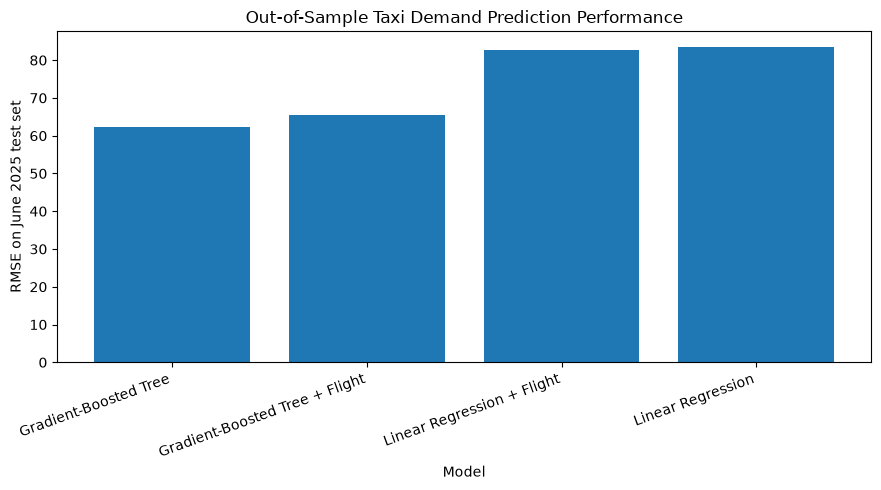

In [98]:
plt.figure(figsize=(9, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["RMSE"]
)

plt.ylabel("RMSE on June 2025 test set")
plt.xlabel("Model")
plt.title("Out-of-Sample Taxi Demand Prediction Performance")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(
    "../plots/model_rmse_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The temporal Gradient-Boosted Tree achieved the strongest out-of-sample performance, with the lowest RMSE and MAE and the highest R² on the June 2025 test set. Adding lagged scheduled flight arrivals slightly improved the Linear Regression model, but did not improve the more flexible Gradient-Boosted Tree model.

This suggests that much of the apparent relationship between scheduled flight arrivals and taxi demand is already captured by recurring temporal patterns. Scheduled flight information therefore provides limited incremental predictive value once nonlinear temporal structure is modelled.

The temporal Gradient-Boosted Tree is consequently selected as the final model for the operational recommendation analysis.

## 5. Save Final Model Predictions

The temporal Gradient-Boosted Tree achieved the strongest out-of-sample performance and is therefore selected as the final predictive model. Its June 2025 predictions are saved for the subsequent operational recommendation analysis.

In [96]:
FINAL_PREDICTIONS_PATH = "../data/processed/final_gbt_predictions.parquet"

final_predictions = (
    gbt_baseline_predictions
    .select(
        "airport",
        "hour",
        "hour_of_day",
        "day_of_week",
        "month",
        "taxi_pickups",
        F.col("prediction").alias("predicted_taxi_pickups")
    )
)

(
    final_predictions
    .write
    .mode("overwrite")
    .parquet(FINAL_PREDICTIONS_PATH)
)

print("Final GBT predictions saved to:")
print(FINAL_PREDICTIONS_PATH)

Final GBT predictions saved to:
../data/processed/final_gbt_predictions.parquet


In [97]:
saved_predictions = spark.read.parquet(
    FINAL_PREDICTIONS_PATH
)

print("Saved rows:", saved_predictions.count())
print("Saved columns:", saved_predictions.columns)

saved_predictions.groupBy("airport").count().orderBy("airport").show()

Saved rows: 1440
Saved columns: ['airport', 'hour', 'hour_of_day', 'day_of_week', 'month', 'taxi_pickups', 'predicted_taxi_pickups']
+-------+-----+
|airport|count|
+-------+-----+
|    JFK|  720|
|    LGA|  720|
+-------+-----+

